In [ ]:
# ✅ RANDOM SEED SETUP
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # For GPU determinism

# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_ffn = ffn_layer(emotion_mha_norm)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_mha_norm)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_ffn = ffn_layer(violence_mha_norm)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_mha_norm)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_ffn = ffn_layer(aggressive_mha_norm)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_mha_norm)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_ffn = ffn_layer(sentiment_mha_norm)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_mha_norm)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))


Num GPUs Available:  1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


tf_model.h5:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on a down-stream task to be ab

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 147ms/step - aggressive_output_accuracy: 0.7009 - aggressive_output_loss: 0.8901 - emotion_output_accuracy: 0.2777 - emotion_output_loss: 2.2208 - loss: 5.8722 - sentiment_output_accuracy: 0.5953 - sentiment_output_loss: 1.0350 - violence_output_accuracy: 0.3687 - violence_output_loss: 1.7263
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 138s 150ms/step - aggressive_output_accuracy: 0.8706 - aggressive_output_loss: 0.3307 - emotion_output_accuracy: 0.5180 - emotion_output_loss: 1.2516 - loss: 3.2004 - sentiment_output_accuracy: 0.7455 - sentiment_output_loss: 0.5388 - violence_output_accuracy: 0.4281 - violence_output_loss: 1.0793
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 101s 150ms/step - aggressive_output_accuracy: 0.8894 - aggressive_output_loss: 0.2936 - emotion_output_accuracy: 0.5828 - emotion_output_loss: 1.0575 - loss: 2.8210 - sentiment_output_accuracy: 0.7736 - sentiment_output_loss: 0.4988 - violence_output_accuracy: 0.4647 - violence_out

# **without mha layer**

In [ ]:
# ✅ RANDOM SEED SETUP
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # For GPU determinism

# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without MHA)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_ffn = ffn_layer(emotion_seq)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without MHA)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_ffn = ffn_layer(violence_seq)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without MHA)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_ffn = ffn_layer(aggressive_seq)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without MHA)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_ffn = ffn_layer(sentiment_seq)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 124s 142ms/step - aggressive_output_accuracy: 0.7000 - aggressive_output_loss: 1.0017 - emotion_output_accuracy: 0.2514 - emotion_output_loss: 2.6364 - loss: 6.5324 - sentiment_output_accuracy: 0.5816 - sentiment_output_loss: 1.1401 - violence_output_accuracy: 0.3802 - violence_output_loss: 1.7542
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 141s 142ms/step - aggressive_output_accuracy: 0.8669 - aggressive_output_loss: 0.3294 - emotion_output_accuracy: 0.4936 - emotion_output_loss: 1.3041 - loss: 3.1277 - sentiment_output_accuracy: 0.7553 - sentiment_output_loss: 0.5265 - violence_output_accuracy: 0.5292 - violence_output_loss: 0.9677
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 142ms/step - aggressive_output_accuracy: 0.8792 - aggressive_output_loss: 0.2883 - emotion_output_accuracy: 0.5632 - emotion_output_loss: 1.1208 - loss: 2.7274 - sentiment_output_accuracy: 0.7701 - sentiment_output_loss: 0.4925 - violence_output_accuracy: 0.6242 - violence_out

In [ ]:
#without random seed
# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
import numpy as np
import tensorflow as tf

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without MHA)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_ffn = ffn_layer(emotion_seq)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without MHA)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_ffn = ffn_layer(violence_seq)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without MHA)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_ffn = ffn_layer(aggressive_seq)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without MHA)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_ffn = ffn_layer(sentiment_seq)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you ar

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 114s 96ms/step - aggressive_output_accuracy: 0.6683 - aggressive_output_loss: 1.0724 - emotion_output_accuracy: 0.2676 - emotion_output_loss: 2.5266 - loss: 6.6070 - sentiment_output_accuracy: 0.5747 - sentiment_output_loss: 1.3667 - violence_output_accuracy: 0.4019 - violence_output_loss: 1.6413
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 69s 103ms/step - aggressive_output_accuracy: 0.8691 - aggressive_output_loss: 0.3297 - emotion_output_accuracy: 0.4593 - emotion_output_loss: 1.3217 - loss: 3.1845 - sentiment_output_accuracy: 0.7318 - sentiment_output_loss: 0.5482 - violence_output_accuracy: 0.5204 - violence_output_loss: 0.9849
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 82s 103ms/step - aggressive_output_accuracy: 0.8752 - aggressive_output_loss: 0.2900 - emotion_output_accuracy: 0.5352 - emotion_output_loss: 1.1628 - loss: 2.7874 - sentiment_output_accuracy: 0.7475 - sentiment_output_loss: 0.4991 - violence_output_accuracy: 0.6205 - violence_output

# **Without FFN layer**

In [ ]:
# ✅ RANDOM SEED SETUP
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # For GPU determinism

# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without FFN)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_attention = attention_layer(emotion_mha_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without FFN)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_attention = attention_layer(violence_mha_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without FFN)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_attention = attention_layer(aggressive_mha_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without FFN)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_attention = attention_layer(sentiment_mha_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


tf_model.h5:   0%|          | 0.00/1.56G [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be ab

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 129s 139ms/step - aggressive_output_accuracy: 0.7439 - aggressive_output_loss: 0.6135 - emotion_output_accuracy: 0.3042 - emotion_output_loss: 1.7559 - loss: 4.3441 - sentiment_output_accuracy: 0.6237 - sentiment_output_loss: 0.7686 - violence_output_accuracy: 0.4434 - violence_output_loss: 1.2062
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 95s 141ms/step - aggressive_output_accuracy: 0.8714 - aggressive_output_loss: 0.3062 - emotion_output_accuracy: 0.5584 - emotion_output_loss: 1.1178 - loss: 2.7869 - sentiment_output_accuracy: 0.7585 - sentiment_output_loss: 0.5107 - violence_output_accuracy: 0.5967 - violence_output_loss: 0.8522
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 95s 140ms/step - aggressive_output_accuracy: 0.8825 - aggressive_output_loss: 0.2749 - emotion_output_accuracy: 0.6178 - emotion_output_loss: 0.9966 - loss: 2.4692 - sentiment_output_accuracy: 0.7802 - sentiment_output_loss: 0.4803 - violence_output_accuracy: 0.6691 - violence_outpu

In [ ]:
#without random seed
# ✅ IMPORTS
import os
import numpy as np
import tensorflow as tf
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, MultiHeadAttention, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without FFN)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_mha = MultiHeadAttention(num_heads=4, key_dim=64)(emotion_seq, emotion_seq)
emotion_mha_norm = LayerNormalization(epsilon=1e-6)(emotion_mha + emotion_seq)
emotion_attention = attention_layer(emotion_mha_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without FFN)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_mha = MultiHeadAttention(num_heads=4, key_dim=64)(violence_seq, violence_seq)
violence_mha_norm = LayerNormalization(epsilon=1e-6)(violence_mha + violence_seq)
violence_attention = attention_layer(violence_mha_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without FFN)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_mha = MultiHeadAttention(num_heads=4, key_dim=64)(aggressive_seq, aggressive_seq)
aggressive_mha_norm = LayerNormalization(epsilon=1e-6)(aggressive_mha + aggressive_seq)
aggressive_attention = attention_layer(aggressive_mha_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without FFN)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_mha = MultiHeadAttention(num_heads=4, key_dim=64)(sentiment_seq, sentiment_seq)
sentiment_mha_norm = LayerNormalization(epsilon=1e-6)(sentiment_mha + sentiment_seq)
sentiment_attention = attention_layer(sentiment_mha_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 99ms/step - aggressive_output_accuracy: 0.7682 - aggressive_output_loss: 0.5163 - emotion_output_accuracy: 0.3115 - emotion_output_loss: 1.7626 - loss: 4.2307 - sentiment_output_accuracy: 0.6423 - sentiment_output_loss: 0.6919 - violence_output_accuracy: 0.4026 - violence_output_loss: 1.2599
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 121s 100ms/step - aggressive_output_accuracy: 0.8753 - aggressive_output_loss: 0.3024 - emotion_output_accuracy: 0.5434 - emotion_output_loss: 1.1939 - loss: 2.8665 - sentiment_output_accuracy: 0.7524 - sentiment_output_loss: 0.5213 - violence_output_accuracy: 0.6171 - violence_output_loss: 0.8488
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 66s 98ms/step - aggressive_output_accuracy: 0.8809 - aggressive_output_loss: 0.2967 - emotion_output_accuracy: 0.6134 - emotion_output_loss: 0.9895 - loss: 2.5053 - sentiment_output_accuracy: 0.7539 - sentiment_output_loss: 0.4859 - violence_output_accuracy: 0.6727 - violence_output

# **without mha and ffn layer**

In [ ]:
# ✅ RANDOM SEED SETUP
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # For GPU determinism

# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without MHA and FFN)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_attention = attention_layer(emotion_seq)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without MHA and FFN)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_attention = attention_layer(violence_seq)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without MHA and FFN)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_attention = attention_layer(aggressive_seq)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without MHA and FFN)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_attention = attention_layer(sentiment_seq)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 133ms/step - aggressive_output_accuracy: 0.6370 - aggressive_output_loss: 0.6816 - emotion_output_accuracy: 0.2096 - emotion_output_loss: 1.7873 - loss: 4.2571 - sentiment_output_accuracy: 0.5404 - sentiment_output_loss: 0.6894 - violence_output_accuracy: 0.4620 - violence_output_loss: 1.0989
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - aggressive_output_accuracy: 0.7897 - aggressive_output_loss: 0.6352 - emotion_output_accuracy: 0.4270 - emotion_output_loss: 1.7606 - loss: 4.1490 - sentiment_output_accuracy: 0.6954 - sentiment_output_loss: 0.6702 - violence_output_accuracy: 0.5522 - violence_output_loss: 1.0829
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 90s 133ms/step - aggressive_output_accuracy: 0.8067 - aggressive_output_loss: 0.5961 - emotion_output_accuracy: 0.4680 - emotion_output_loss: 1.7336 - loss: 4.0520 - sentiment_output_accuracy: 0.7199 - sentiment_output_loss: 0.6537 - violence_output_accuracy: 0.5777 - violence_outp

In [ ]:
#without random seed
# ✅ IMPORTS
import os
import numpy as np
import tensorflow as tf
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without MHA and FFN)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_attention = attention_layer(emotion_seq)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without MHA and FFN)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_attention = attention_layer(violence_seq)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without MHA and FFN)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_attention = attention_layer(aggressive_seq)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without MHA and FFN)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_attention = attention_layer(sentiment_seq)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 107s 95ms/step - aggressive_output_accuracy: 0.6595 - aggressive_output_loss: 0.6812 - emotion_output_accuracy: 0.2029 - emotion_output_loss: 1.7864 - loss: 4.2543 - sentiment_output_accuracy: 0.5616 - sentiment_output_loss: 0.6894 - violence_output_accuracy: 0.3680 - violence_output_loss: 1.0973
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 65s 94ms/step - aggressive_output_accuracy: 0.8008 - aggressive_output_loss: 0.6343 - emotion_output_accuracy: 0.3276 - emotion_output_loss: 1.7592 - loss: 4.1425 - sentiment_output_accuracy: 0.6532 - sentiment_output_loss: 0.6702 - violence_output_accuracy: 0.5775 - violence_output_loss: 1.0789
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step - aggressive_output_accuracy: 0.7970 - aggressive_output_loss: 0.5983 - emotion_output_accuracy: 0.4614 - emotion_output_loss: 1.7328 - loss: 4.0491 - sentiment_output_accuracy: 0.7164 - sentiment_output_loss: 0.6555 - violence_output_accuracy: 0.5537 - violence_output_l

# **without shared attention layer**

In [ ]:
#without random seed
# ✅ IMPORTS
import os
import random
import numpy as np
import tensorflow as tf
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without MultiHeadAttention)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_ffn = ffn_layer(emotion_seq)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_seq)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without MultiHeadAttention)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_ffn = ffn_layer(violence_seq)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_seq)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without MultiHeadAttention)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_ffn = ffn_layer(aggressive_seq)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_seq)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without MultiHeadAttention)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_ffn = ffn_layer(sentiment_seq)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_seq)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=15, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/kernel:0', 'bert/pooler/dense/bias:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 113s 98ms/step - aggressive_output_accuracy: 0.7430 - aggressive_output_loss: 0.7722 - emotion_output_accuracy: 0.2892 - emotion_output_loss: 2.1926 - loss: 5.2116 - sentiment_output_accuracy: 0.6399 - sentiment_output_loss: 0.7914 - violence_output_accuracy: 0.4008 - violence_output_loss: 1.4554
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 126s 102ms/step - aggressive_output_accuracy: 0.8645 - aggressive_output_loss: 0.3221 - emotion_output_accuracy: 0.4904 - emotion_output_loss: 1.2512 - loss: 2.9453 - sentiment_output_accuracy: 0.7577 - sentiment_output_loss: 0.5139 - violence_output_accuracy: 0.5950 - violence_output_loss: 0.8581
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - aggressive_output_accuracy: 0.8886 - aggressive_output_loss: 0.2777 - emotion_output_accuracy: 0.5742 - emotion_output_loss: 1.0698 - loss: 2.5550 - sentiment_output_accuracy: 0.7933 - sentiment_output_loss: 0.4743 - violence_output_accuracy: 0.6720 - violence_outpu

In [ ]:
# ✅ RANDOM SEED SETUP
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'  # For GPU determinism

# ✅ IMPORTS
import pandas as pd
from transformers import TFAutoModel, AutoTokenizer
from tensorflow.keras.layers import Input, Dense, Layer, LayerNormalization
from tensorflow.keras.models import Model
from sklearn.utils import class_weight
from sklearn.metrics import classification_report

# ✅ GPU Check
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

# ✅ Load model/tokenizer
muril_model_name = "google/muril-base-cased"
tokenizer = AutoTokenizer.from_pretrained(muril_model_name)

# ✅ Load datasets
em_train_df = pd.read_csv('/content/em-train-balanced.csv')
vi_train_df = pd.read_csv('/content/vio-train-balanced.csv')
ag_binary_train_df = pd.read_csv('/content/ag-train-binary-balanced.csv')
snt_train_df = pd.read_csv('/content/snt_balanced_train.csv')

vi_val_df = pd.read_csv("/content/vio-dev-balanced.csv")
ag_val_df = pd.read_csv("/content/ag-val-binary-balanced.csv")
em_val_df = pd.read_csv("/content/em-val-balanced.csv")
snt_val_df = pd.read_csv('/content/snt_balanced_dev.csv')

vi_test_df = pd.read_csv("/content/vio-test-balanced.csv")
ag_test_df = pd.read_csv("/content/ag-test-binary-balanced.csv")
em_test_df = pd.read_csv("/content/em-test-balanced.csv")
snt_test_df = pd.read_csv('/content/snt_balanced_test.csv')

# ✅ Tokenization
def tokenize_texts(texts, max_length=100):
    return tokenizer(
        texts.tolist(),
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_tensors='tf'
    )

max_length = 100

emotion_encodings = tokenize_texts(em_train_df['text'], max_length)
violence_encodings = tokenize_texts(vi_train_df['text'], max_length)
aggressive_encodings = tokenize_texts(ag_binary_train_df['text'], max_length)
sentiment_encodings = tokenize_texts(snt_train_df['text'], max_length)

emotion_eval_encodings = tokenize_texts(em_val_df['text'], max_length)
violence_eval_encodings = tokenize_texts(vi_val_df['text'], max_length)
aggressive_eval_encodings = tokenize_texts(ag_val_df['text'], max_length)
sentiment_eval_encodings = tokenize_texts(snt_val_df['text'], max_length)

emotion_test_encodings = tokenize_texts(em_test_df['text'], max_length)
violence_test_encodings = tokenize_texts(vi_test_df['text'], max_length)
aggressive_test_encodings = tokenize_texts(ag_test_df['text'], max_length)
sentiment_test_encodings = tokenize_texts(snt_test_df['text'], max_length)

# ✅ Labels
emotion_labels = np.array(em_train_df['label'])
violence_labels = np.array(vi_train_df['label'])
aggressive_labels = np.array(ag_binary_train_df['label'])
sentiment_labels = np.array(snt_train_df['label'])

emotion_val_labels = np.array(em_val_df['label'])
violence_val_labels = np.array(vi_val_df['label'])
aggressive_val_labels = np.array(ag_val_df['label'])
sentiment_val_labels = np.array(snt_val_df['label'])

emotion_test_labels = np.array(em_test_df['label'])
violence_test_labels = np.array(vi_test_df['label'])
aggressive_test_labels = np.array(ag_test_df['label'])
sentiment_test_labels = np.array(snt_test_df['label'])

# ✅ Class Weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(violence_labels),
    y=violence_labels
)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}

def weighted_sparse_categorical_crossentropy(class_weights):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        weights = tf.gather([class_weights[i] for i in range(len(class_weights))], y_true)
        weights = tf.cast(weights, tf.float32)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        return tf.reduce_mean(loss * weights)
    return loss_fn

# ✅ Custom Layers
class MURILLayer(Layer):
    def __init__(self, model_name, **kwargs):
        super(MURILLayer, self).__init__(**kwargs)
        self.model = TFAutoModel.from_pretrained(model_name)

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

class AttentionLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1), initializer="random_normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1), initializer="zeros")
        super(AttentionLayer, self).build(input_shape)

    def call(self, inputs):
        e = tf.keras.backend.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        a = tf.keras.backend.softmax(e, axis=1)
        output = tf.reduce_sum(inputs * a, axis=1)
        return output

def ffn_layer(hidden, output_dim=768):
    dense = Dense(1024, activation='relu')(hidden)
    proj = Dense(output_dim)(dense)
    return proj

# ✅ Input Layers
emotion_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='emotion_input_ids')
emotion_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='emotion_attention_mask')
violence_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='violence_input_ids')
violence_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='violence_attention_mask')
aggressive_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_input_ids')
aggressive_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='aggressive_attention_mask')
sentiment_input_ids = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_input_ids')
sentiment_attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='sentiment_attention_mask')

muril_layer = MURILLayer(model_name=muril_model_name)
attention_layer = AttentionLayer()

# ✅ Emotion Branch (without MultiHeadAttention)
emotion_seq = muril_layer([emotion_input_ids, emotion_attention_mask])
emotion_ffn = ffn_layer(emotion_seq)
emotion_ffn_norm = LayerNormalization(epsilon=1e-6)(emotion_ffn + emotion_seq)
emotion_attention = attention_layer(emotion_ffn_norm)
emotion_output = Dense(6, activation='softmax', name='emotion_output')(emotion_attention)

# ✅ Violence Branch (without MultiHeadAttention)
violence_seq = muril_layer([violence_input_ids, violence_attention_mask])
violence_ffn = ffn_layer(violence_seq)
violence_ffn_norm = LayerNormalization(epsilon=1e-6)(violence_ffn + violence_seq)
violence_attention = attention_layer(violence_ffn_norm)
violence_output = Dense(3, activation='softmax', name='violence_output')(violence_attention)

# ✅ Aggression Branch (without MultiHeadAttention)
aggressive_seq = muril_layer([aggressive_input_ids, aggressive_attention_mask])
aggressive_ffn = ffn_layer(aggressive_seq)
aggressive_ffn_norm = LayerNormalization(epsilon=1e-6)(aggressive_ffn + aggressive_seq)
aggressive_attention = attention_layer(aggressive_ffn_norm)
aggressive_output = Dense(2, activation='softmax', name='aggressive_output')(aggressive_attention)

# ✅ Sentiment Branch (without MultiHeadAttention)
sentiment_seq = muril_layer([sentiment_input_ids, sentiment_attention_mask])
sentiment_ffn = ffn_layer(sentiment_seq)
sentiment_ffn_norm = LayerNormalization(epsilon=1e-6)(sentiment_ffn + sentiment_seq)
sentiment_attention = attention_layer(sentiment_ffn_norm)
sentiment_output = Dense(2, activation='softmax', name='sentiment_output')(sentiment_attention)

# ✅ Build Model
model = Model(
    inputs={
        'emotion_input_ids': emotion_input_ids,
        'emotion_attention_mask': emotion_attention_mask,
        'violence_input_ids': violence_input_ids,
        'violence_attention_mask': violence_attention_mask,
        'aggressive_input_ids': aggressive_input_ids,
        'aggressive_attention_mask': aggressive_attention_mask,
        'sentiment_input_ids': sentiment_input_ids,
        'sentiment_attention_mask': sentiment_attention_mask
    },
    outputs=[emotion_output, violence_output, aggressive_output, sentiment_output]
)

# ✅ Compile Model
model.compile(
    optimizer='adam',
    loss={
        'emotion_output': 'sparse_categorical_crossentropy',
        'violence_output': weighted_sparse_categorical_crossentropy(class_weights_dict),
        'aggressive_output': 'sparse_categorical_crossentropy',
        'sentiment_output': 'sparse_categorical_crossentropy'
    },
    loss_weights={
        'emotion_output': 1.0,
        'violence_output': 1.0,
        'aggressive_output': 1.0,
        'sentiment_output': 1.0
    },
    metrics={
        'emotion_output': 'accuracy',
        'violence_output': 'accuracy',
        'aggressive_output': 'accuracy',
        'sentiment_output': 'accuracy'
    }
)

# ✅ Prepare Training Data
train_data = {
    'emotion_input_ids': emotion_encodings['input_ids'],
    'emotion_attention_mask': emotion_encodings['attention_mask'],
    'violence_input_ids': violence_encodings['input_ids'],
    'violence_attention_mask': violence_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_encodings['attention_mask']
}

train_labels = {
    'emotion_output': emotion_labels,
    'violence_output': violence_labels,
    'aggressive_output': aggressive_labels,
    'sentiment_output': sentiment_labels
}

# ✅ Train
model.fit(x=train_data, y=train_labels, epochs=5, batch_size=4)

# ✅ Save
model.save("/content/muril_multitask_model.keras")

# ✅ Evaluation
eval_data = {
    'emotion_input_ids': emotion_eval_encodings['input_ids'],
    'emotion_attention_mask': emotion_eval_encodings['attention_mask'],
    'violence_input_ids': violence_eval_encodings['input_ids'],
    'violence_attention_mask': violence_eval_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_eval_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_eval_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_eval_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_eval_encodings['attention_mask']
}

val_preds = model.predict(eval_data)
val_preds_labels = [np.argmax(p, axis=1) for p in val_preds]

print("\n📊 Validation Classification Reports:")
print("Emotion:")
print(classification_report(emotion_val_labels, val_preds_labels[0]))
print("Violence:")
print(classification_report(violence_val_labels, val_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_val_labels, val_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_val_labels, val_preds_labels[3]))

# ✅ Test
test_data = {
    'emotion_input_ids': emotion_test_encodings['input_ids'],
    'emotion_attention_mask': emotion_test_encodings['attention_mask'],
    'violence_input_ids': violence_test_encodings['input_ids'],
    'violence_attention_mask': violence_test_encodings['attention_mask'],
    'aggressive_input_ids': aggressive_test_encodings['input_ids'],
    'aggressive_attention_mask': aggressive_test_encodings['attention_mask'],
    'sentiment_input_ids': sentiment_test_encodings['input_ids'],
    'sentiment_attention_mask': sentiment_test_encodings['attention_mask']
}

test_preds = model.predict(test_data)
test_preds_labels = [np.argmax(p, axis=1) for p in test_preds]

print("\n📊 Test Classification Reports:")
print("Emotion:")
print(classification_report(emotion_test_labels, test_preds_labels[0]))
print("Violence:")
print(classification_report(violence_test_labels, test_preds_labels[1]))
print("Aggression:")
print(classification_report(aggressive_test_labels, test_preds_labels[2]))
print("Sentiment:")
print(classification_report(sentiment_test_labels, test_preds_labels[3]))

Num GPUs Available:  1


Some layers from the model checkpoint at google/muril-base-cased were not used when initializing TFBertModel: ['mlm___cls']
- This IS expected if you are initializing TFBertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFBertModel were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['bert/pooler/dense/bias:0', 'bert/pooler/dense/kernel:0']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 126s 145ms/step - aggressive_output_accuracy: 0.7344 - aggressive_output_loss: 0.7587 - emotion_output_accuracy: 0.2895 - emotion_output_loss: 2.3039 - loss: 5.5225 - sentiment_output_accuracy: 0.6470 - sentiment_output_loss: 0.7824 - violence_output_accuracy: 0.4136 - violence_output_loss: 1.6774
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 97s 144ms/step - aggressive_output_accuracy: 0.8658 - aggressive_output_loss: 0.3206 - emotion_output_accuracy: 0.5082 - emotion_output_loss: 1.2516 - loss: 3.0113 - sentiment_output_accuracy: 0.7542 - sentiment_output_loss: 0.5165 - violence_output_accuracy: 0.5541 - violence_output_loss: 0.9225
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 97s 144ms/step - aggressive_output_accuracy: 0.8809 - aggressive_output_loss: 0.2845 - emotion_output_accuracy: 0.5708 - emotion_output_loss: 1.0924 - loss: 2.6576 - sentiment_output_accuracy: 0.7733 - sentiment_output_loss: 0.4863 - violence_output_accuracy: 0.6415 - violence_output_l

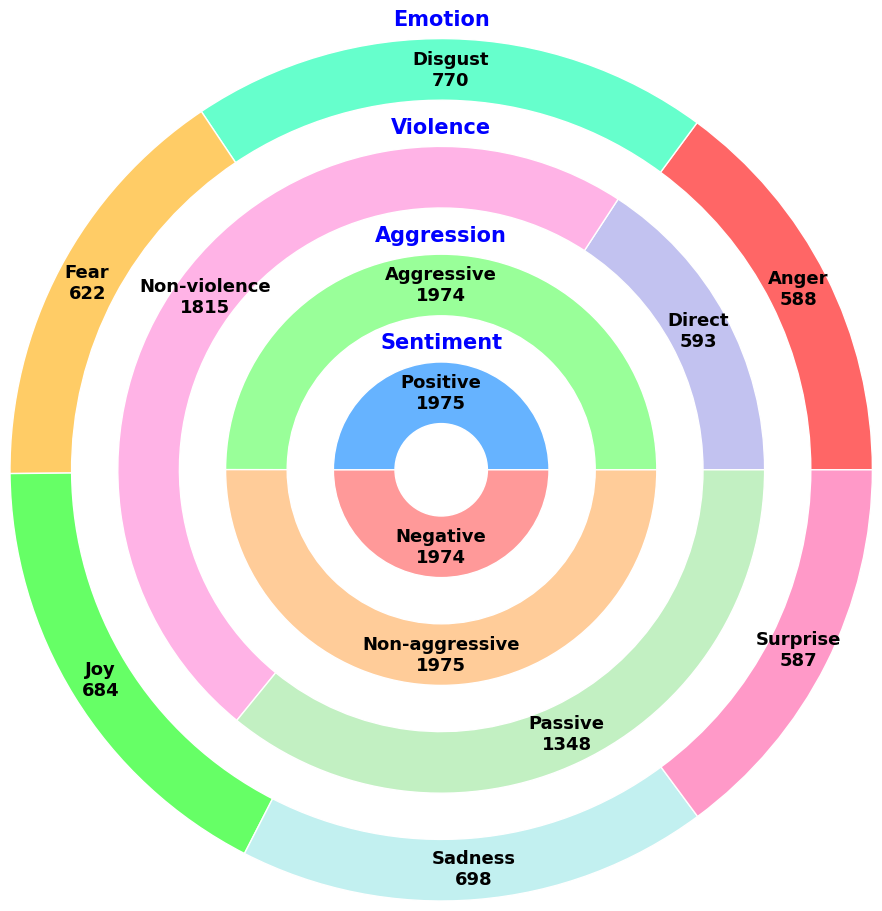

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =======================
# Dataset totals
# =======================
data = {
    "Sentiment": {"Positive": 1975, "Negative": 1974},
    "Aggression": {"Aggressive": 1974, "Non-aggressive": 1975},
    "Violence": {"Direct": 593, "Non-violence": 1815, "Passive": 1348},
    "Emotion": {
        "Anger": 588,
        "Disgust": 770,
        "Fear": 622,
        "Joy": 684,
        "Sadness": 698,
        "Surprise": 587
    }
}

# =======================
# Plot nested circles
# =======================
fig, ax = plt.subplots(figsize=(10, 10))

tasks = ["Sentiment", "Aggression", "Violence", "Emotion"]
sizes_list = [list(data[t].values()) for t in tasks]
labels_list = [list(data[t].keys()) for t in tasks]
colors_list = [
    ["#66b3ff", "#ff9999"],  # Sentiment
    ["#99ff99", "#ffcc99"],  # Aggression
    ["#c2c2f0", "#ffb3e6", "#c2f0c2"],  # Violence
    ["#ff6666", "#66ffcc", "#ffcc66", "#66ff66", "#c2f0f0", "#ff99c8"]  # Emotion
]

# Ring width and spacing
width = 0.2
gap = 0.15

# Draw concentric pie charts with class names inside wedges
for i, (sizes, labels, colors, task) in enumerate(zip(sizes_list, labels_list, colors_list, tasks)):
    radius = (i + 1) * (width + gap)
    wedges, _ = ax.pie(
        sizes,
        radius=radius,
        colors=colors,
        wedgeprops=dict(width=width, edgecolor="white")
    )

    # Place task name CLOSER to the circle and make it blue
    ax.text(
        0, radius + 0.03,
        task,
        ha="center", va="bottom", fontsize=15, fontweight="bold",
        color="blue"
    )

    # Place class names + counts INSIDE each wedge
    for wedge, label, size in zip(wedges, labels, sizes):
        angle = (wedge.theta2 + wedge.theta1) / 2  # midpoint angle of wedge
        r = radius - width / 2
        x = r * np.cos(np.deg2rad(angle))
        y = r * np.sin(np.deg2rad(angle))
        ax.text(x, y, f"{label}\n{size}", ha="center", va="center", fontsize=13, weight="bold")

ax.set(aspect="equal")
plt.show()
